# Train VI viscosity model — TEST spin-up

Build VI-ready bundles from **test** spin-up `_grid.npz` files, then run field variational inference to recover **log-viscosity** from noisy surface-speed observations.

| Step | Output |
|------|--------|
| Prep test bundles | `outputs/vi/test/vi_case_<case_id>.npz`, `manifest.json` |
| Train VI | posterior mean/std viscosity on the grounded grid |
| Save | `outputs/vi/test/results_<case_id>.npz` |

Core logic: `scripts/prep_vi_dataset.py` (data prep) and `scripts/vi_viscosity_model.py` (inference).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "scripts" / "project_paths.py").exists()
)
sys.path.insert(0, str(ROOT / "scripts"))

from project_paths import TEST_CASES
from prep_vi_dataset import (
    NoiseConfig,
    build_manifest,
    compute_normalization,
    prepare_case,
    read_jsonable,
)
from vi_viscosity_model import VITrainingConfig, evaluate_case, load_vi_bundle

## Configuration

In [2]:
OUTPUT_DIR = ROOT / "outputs" / "vi" / "test"
NOISE = NoiseConfig(relative_speed_sigma=0.02, seed=42)
CASE_ID = "more_sliding"  # or "no_sliding"

VI_CONFIG = VITrainingConfig(
    coarse_stride=16,
    prior_log_visc_std=0.79,
    smoothness_passes=3,
    smoothness_blend=0.25,
)

CASE_SPECS = {
    case_id: {
        "source_npz": TEST_CASES[case_id]["grid_npz"],
        "sliding_regime": TEST_CASES[case_id]["sliding_regime"],
    }
    for case_id in TEST_CASES
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"VI output dir: {OUTPUT_DIR.relative_to(ROOT)}")
for case_id, spec in CASE_SPECS.items():
    path = spec["source_npz"]
    print(f"{case_id}: {path.relative_to(ROOT)} {'✓' if path.is_file() else 'MISSING'}")

VI output dir: outputs/vi/test
more_sliding: outputs/spinup/test/more_sliding/SteadyState_more_sliding_test_200yr_ramp4000_1refine_grid.npz ✓
no_sliding: outputs/spinup/test/no_sliding/SteadyState_no_sliding_test_200yr_ramp4000_1refine_grid.npz ✓


## Prepare test VI bundles

Reads test `_grid.npz`, adds masks and noisy `speed_obs`, writes per-case VI bundles.

In [3]:
rng = np.random.default_rng(NOISE.seed)
entries = []
prepared_fields = {}

for case_id, spec in CASE_SPECS.items():
    entry, fields = prepare_case(
        case_id,
        spec["source_npz"].resolve(),
        spec["sliding_regime"],
        OUTPUT_DIR,
        NOISE,
        rng,
    )
    entries.append(entry)
    prepared_fields[case_id] = fields
    print(f"Wrote {Path(entry['vi_bundle']).relative_to(ROOT)}")

normalization = compute_normalization(prepared_fields)
VI_CONFIG = VITrainingConfig(
    coarse_stride=VI_CONFIG.coarse_stride,
    prior_log_visc_mean=float(normalization["log_viscosity_true"]["mean"]),
    prior_log_visc_std=float(normalization["log_viscosity_true"]["std"]),
    smoothness_passes=VI_CONFIG.smoothness_passes,
    smoothness_blend=VI_CONFIG.smoothness_blend,
)

manifest_path = OUTPUT_DIR / "manifest.json"
manifest = build_manifest(entries, OUTPUT_DIR, NOISE, normalization)
with manifest_path.open("w", encoding="utf-8") as stream:
    json.dump(read_jsonable(manifest), stream, indent=2, sort_keys=True)
print(f"Wrote {manifest_path.relative_to(ROOT)}")
print(f"Prior log-viscosity: mean={VI_CONFIG.prior_log_visc_mean:.3f}, std={VI_CONFIG.prior_log_visc_std:.3f}")

Wrote outputs/vi/test/vi_case_more_sliding.npz
Wrote outputs/vi/test/vi_case_no_sliding.npz
Wrote outputs/vi/test/manifest.json
Prior log-viscosity: mean=3.044, std=0.972


## Train VI model

1. Fit a local log-speed **surrogate** from the spin-up truth snapshot (`speed_true`, `log_viscosity_true`, geometry).
2. Run **factorized Gaussian VI** on a coarse grounded grid using only `speed_obs` in the likelihood.
3. Interpolate the posterior back to the full grounded domain.

This is a prototype emulator-based VI loop. A full physics-informed version would replace the surrogate with `icepack` `diagnostic_solve` calls.

In [4]:
bundle_path = OUTPUT_DIR / f"vi_case_{CASE_ID}.npz"
result = evaluate_case(bundle_path, VI_CONFIG)

print(f"Case: {result.case_id}")
print(f"ELBO: {result.elbo:.1f}")
print(f"Surrogate log-speed RMSE: {result.metrics['surrogate_log_speed_rmse']:.3f}")
print(
    "Posterior vs truth (log-viscosity): "
    f"R²={result.metrics['r2_log_viscosity']:.3f}, "
    f"RMSE={result.metrics['rmse_log_viscosity']:.3f}"
)
print(
    "Surrogate coefficients: "
    f"intercept={result.surrogate.intercept:.3f}, "
    f"log_h={result.surrogate.log_thickness_coeff:.3f}, "
    f"bed={result.surrogate.bed_coeff:.3f}, "
    f"log_eta={result.surrogate.log_viscosity_coeff:.3f}"
)

Case: more_sliding
ELBO: -1351.3
Surrogate log-speed RMSE: 1.552
Posterior vs truth (log-viscosity): R²=0.262, RMSE=0.642
Surrogate coefficients: intercept=3.720, log_h=0.400, bed=-3.043, log_eta=-1.436


In [5]:
results_path = OUTPUT_DIR / f"results_{CASE_ID}.npz"
bundle = load_vi_bundle(bundle_path)
np.savez_compressed(
    results_path,
    case_id=result.case_id,
    viscosity_mean=result.viscosity_mean,
    viscosity_std=result.viscosity_std,
    log_viscosity_mean=result.mu_log_visc_full,
    log_viscosity_std=result.sigma_log_visc_full,
    viscosity_true=bundle["viscosity_true"],
    log_viscosity_true=result.log_viscosity_true,
    speed_obs=result.speed_obs,
    grounded_mask=result.grounded_mask,
    X=bundle["X"],
    Y=bundle["Y"],
    metrics_json=json.dumps(result.metrics),
)
print(f"Wrote {results_path.relative_to(ROOT)}")

Wrote outputs/vi/test/results_more_sliding.npz


## Posterior vs ground truth

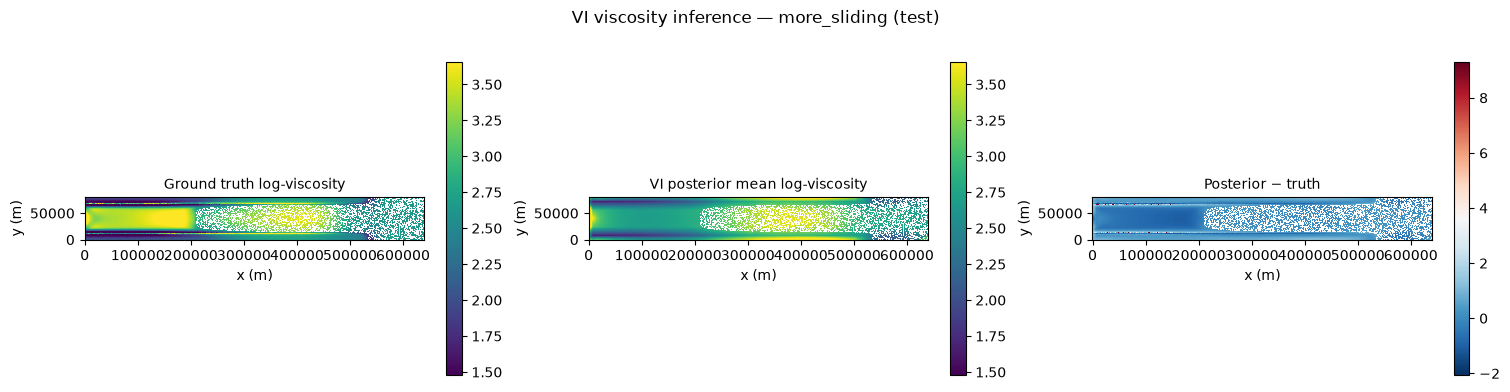

In [6]:
mask = result.grounded_mask
truth = np.where(mask, result.log_viscosity_true, np.nan)
post = np.where(mask, result.mu_log_visc_full, np.nan)
diff = post - truth

vmin = np.nanpercentile(truth, 5)
vmax = np.nanpercentile(truth, 95)
X, Y = bundle["X"], bundle["Y"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, data, title, cmap in (
    (axes[0], truth, "Ground truth log-viscosity", "viridis"),
    (axes[1], post, "VI posterior mean log-viscosity", "viridis"),
    (axes[2], diff, "Posterior − truth", "RdBu_r"),
):
    im = ax.pcolormesh(X, Y, data, shading="auto", cmap=cmap)
    if title.endswith("viscosity"):
        im.set_clim(vmin, vmax)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(f"VI viscosity inference — {CASE_ID} (test)", fontsize=12)
plt.show()

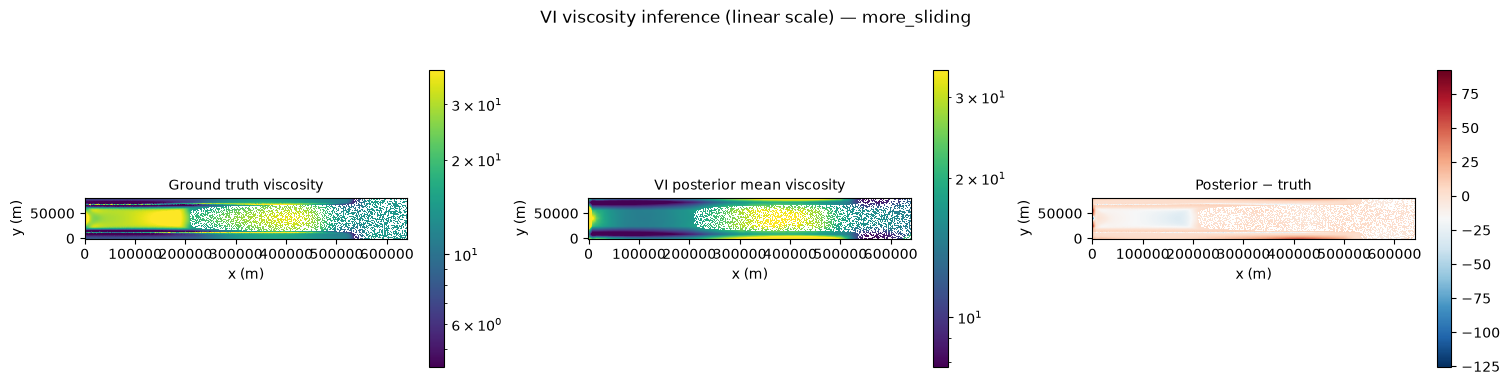

In [7]:
visc_truth = np.where(mask, bundle["viscosity_true"], np.nan)
visc_post = np.where(mask, result.viscosity_mean, np.nan)
visc_diff = visc_post - visc_truth

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, data, title in (
    (axes[0], visc_truth, "Ground truth viscosity"),
    (axes[1], visc_post, "VI posterior mean viscosity"),
    (axes[2], visc_diff, "Posterior − truth"),
):
    positive = data[data > 0]
    vmin = max(float(np.nanpercentile(positive, 5)), 1e-3)
    vmax = float(np.nanpercentile(positive, 95))
    if title.endswith("truth"):
        im = ax.pcolormesh(X, Y, data, shading="auto", cmap="RdBu_r")
    else:
        im = ax.pcolormesh(X, Y, data, shading="auto", cmap="viridis", norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(f"VI viscosity inference (linear scale) — {CASE_ID}", fontsize=12)
plt.show()

## Train both test cases

In [8]:
summary = []
for case_id in CASE_SPECS:
    fit = evaluate_case(OUTPUT_DIR / f"vi_case_{case_id}.npz", VI_CONFIG)
    summary.append(
        {
            "case_id": case_id,
            "r2_log_viscosity": fit.metrics["r2_log_viscosity"],
            "rmse_log_viscosity": fit.metrics["rmse_log_viscosity"],
            "surrogate_log_speed_rmse": fit.metrics["surrogate_log_speed_rmse"],
        }
    )
    print(
        f"{case_id}: R²={fit.metrics['r2_log_viscosity']:.3f}, "
        f"RMSE={fit.metrics['rmse_log_viscosity']:.3f}"
    )

summary

more_sliding: R²=0.262, RMSE=0.642
no_sliding: R²=0.510, RMSE=0.749


[{'case_id': 'more_sliding',
  'r2_log_viscosity': 0.2619212432406095,
  'rmse_log_viscosity': 0.6419228598051132,
  'surrogate_log_speed_rmse': 1.5518628251518136},
 {'case_id': 'no_sliding',
  'r2_log_viscosity': 0.5097408195193562,
  'rmse_log_viscosity': 0.7487963452931425,
  'surrogate_log_speed_rmse': 1.347903360990383}]